<h3> 1. Covering the commodities classes energy and metals </h3>
<p> In this section we will be extracting each price return and extracting features that will help in the prediction of the energy and metals asset classes </p>


In [ ]:
# Setting the imports

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay)
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import shap

In [3]:
# Reading the orginal prices dataframe

prices_df = pd.read_csv('../data/src/ohlcv_data.csv')
prices_df['date'] = pd.to_datetime(prices_df['date'])
prices_df = prices_df.set_index('date')

# Reading the primary signal dataframe
primary_df = pd.read_csv('../data/src/primary_signals.csv')
primary_df['date'] = pd.to_datetime(primary_df['date'])

# Extracting instrument wti
wti_df = prices_df.loc[prices_df['instrument'] == 'cl1s'].copy()
wti_primary_df = primary_df.loc[:,'cl1s'].copy()

# Extracting instrument Heating oil
heating_oil_df = prices_df.loc[prices_df['instrument'] == 'ho1s'].copy()
heating_oil_primary_df = primary_df.loc[:,'ho1s'].copy()

# Extracting RBOB gasoline
rbob_df = prices_df.loc[prices_df['instrument'] == 'rb1s'].copy()
rbob_primary_df = primary_df.loc[:,'rb1s'].copy()

# Extracting natural gas 
natural_gas_df = prices_df.loc[prices_df['instrument'] == 'ng1s'].copy()
natural_gas_primary_df = primary_df.loc[:,'ng1s'].copy()

# Extracting gold
gold_df = prices_df.loc[prices_df['instrument'] == 'gc1s'].copy()
gold_primary_df = primary_df.loc[:,'gc1s'].copy()

# Extracting silver
silver_df = prices_df.loc[prices_df['instrument'] == 'si1s'].copy()
silver_primary_df = primary_df.loc[:,'si1s'].copy()

# Extracting copper
copper_df = prices_df.loc[prices_df['instrument'] == 'hg1s'].copy()
copper_primary_df = primary_df.loc[:,'hg1s'].copy()

# Extracting platinimum 
plat_df = prices_df.loc[prices_df['instrument'] == 'pl1s'].copy()
plat_primary_df = primary_df.loc[:,'pl1s'].copy()

instruments = {
    'WTI': {'price_df': wti_df, 'signal': wti_primary_df},
    'Heating Oil': {'price_df': heating_oil_df, 'signal': heating_oil_primary_df},
    'RBOB Gasoline': {'price_df': rbob_df, 'signal': rbob_primary_df},
    'Natural Gas': {'price_df': natural_gas_df, 'signal': natural_gas_primary_df},
    'Gold': {'price_df': gold_df, 'signal': gold_primary_df},
    'Silver': {'price_df': silver_df, 'signal': silver_primary_df},
    'Copper': {'price_df': copper_df, 'signal': copper_primary_df},
    'Platinum': {'price_df': plat_df, 'signal': plat_primary_df},
}


### 2. Quick Data exploration plotting 
<p> Plotting each asset class for each instrument chosen </p>

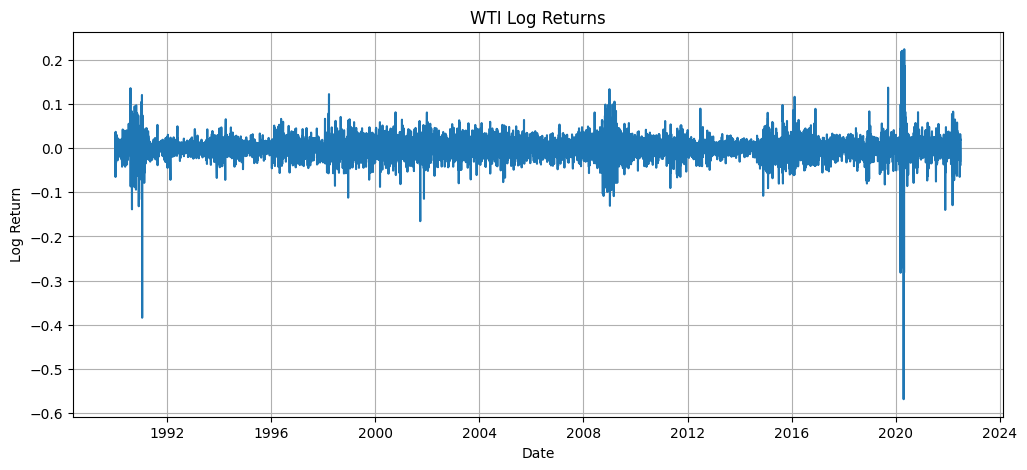

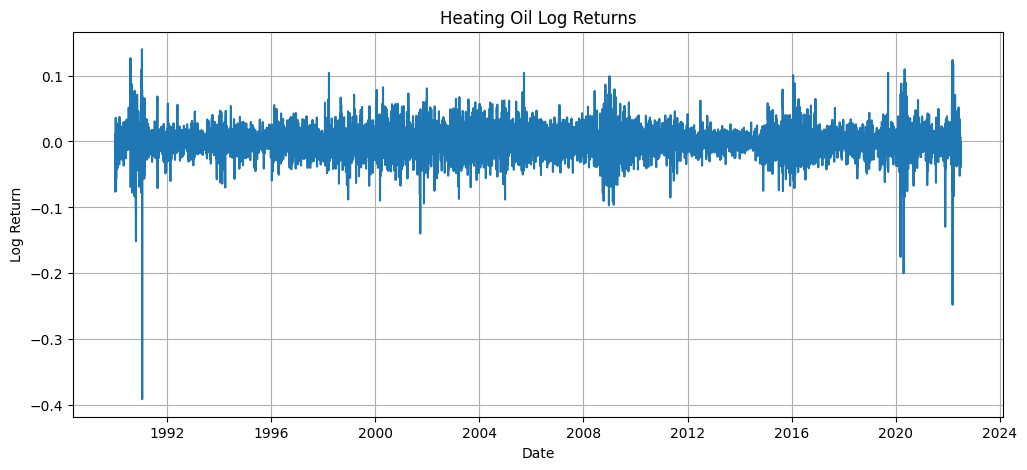

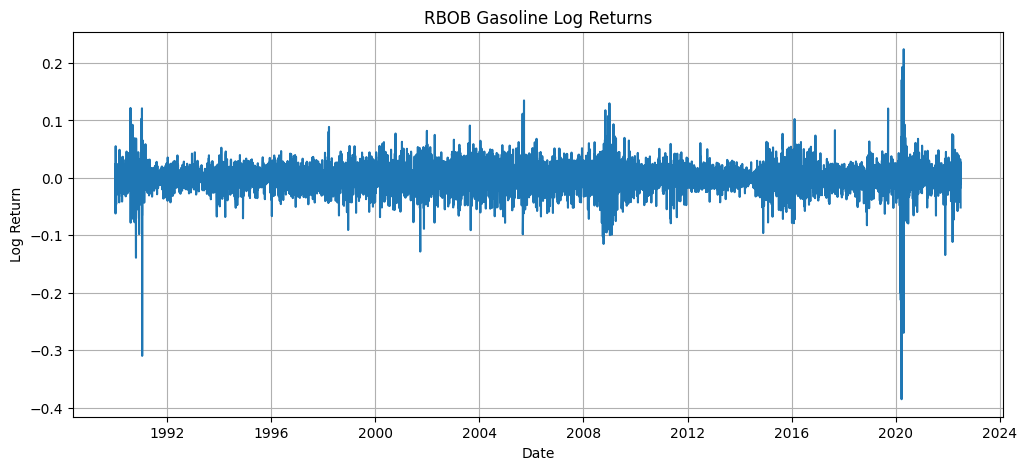

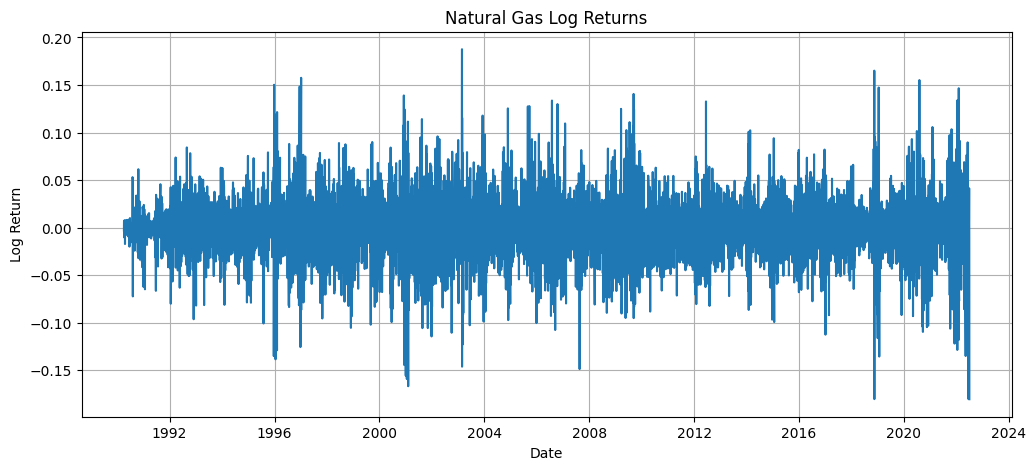

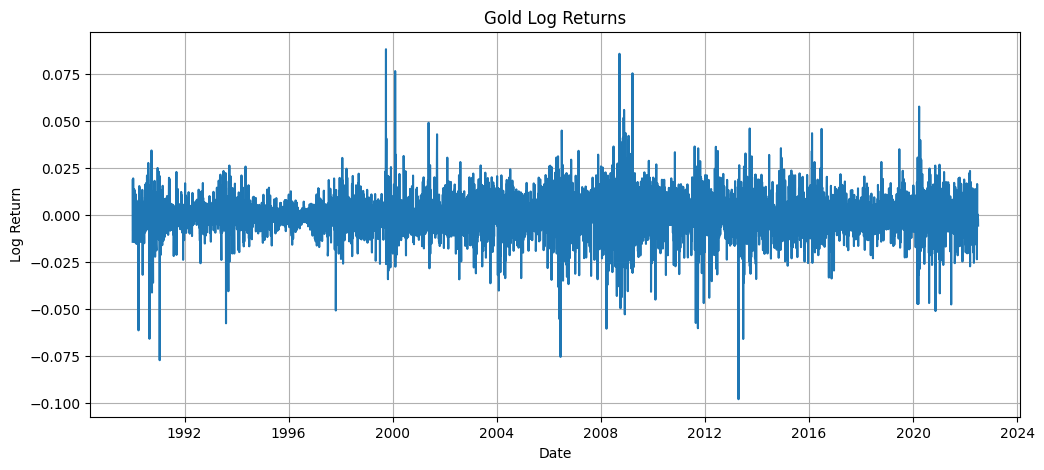

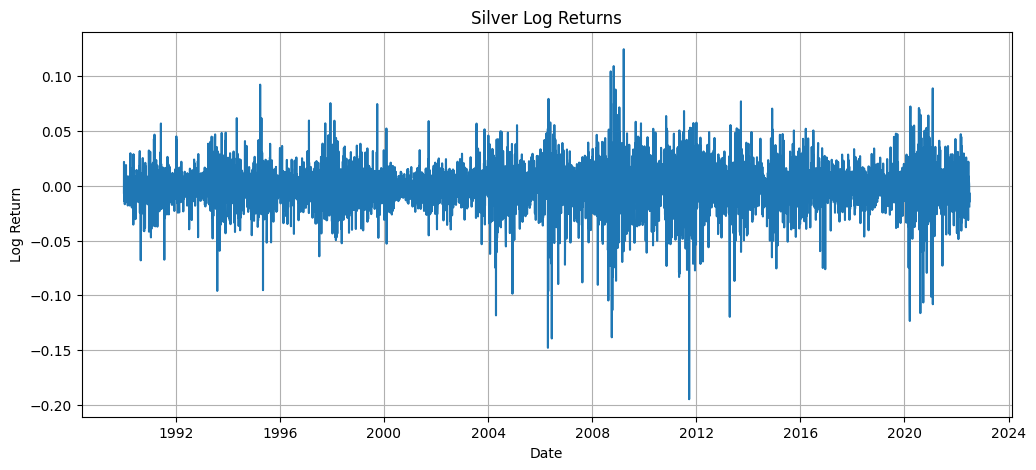

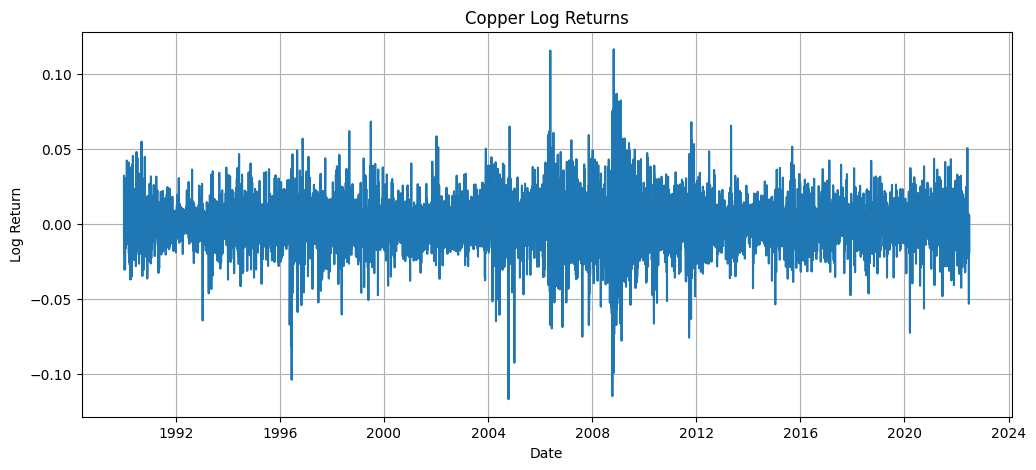

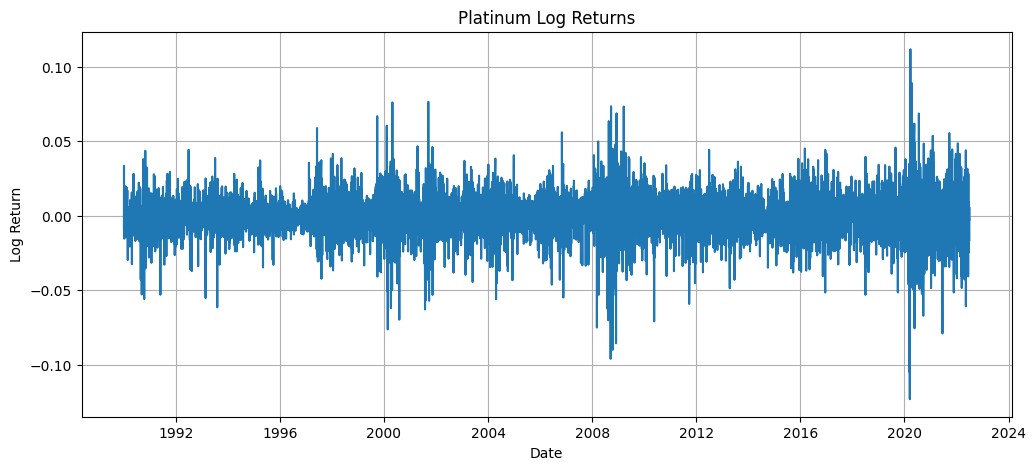

In [4]:
# Getting the returns in each case and plotting them

for instrument,dataframes in instruments.items():
    df = dataframes['price_df']
    df['returns'] = np.log(df['close']/df['close'].shift(1))
    # Plot
    plt.figure(figsize=(12, 5))

    plt.plot(
        df.index,
        df['returns']
    )

    plt.title(f'{instrument} Log Returns')
    plt.xlabel('Date')
    plt.ylabel('Log Return')

    plt.grid(True)

    plt.show()


<h3> 3. Feature engineering </h3>
<p> For each instrument we will be engineering some features, some common technical indicators, HMMs then we will cluster features using PCA then run EM to further cluster down common features </p>

<h4> 3.1 WTI feature engineering </h4>
<p> In this section we will build the features needed in building the meta model for the WTI </p>


In [5]:
# This section entails generic functions for technical indicators which can be used anywhere in the code

def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    # Wilder's smoothing (exponential, not simple moving average)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))



In [6]:
# In this section we will calculate the technical signals

# Calculating realized volatility for wti
wti_df['vol_20'] = wti_df['returns'].rolling(20).std()
wti_df['vol_60'] = wti_df['returns'].rolling(60).std()

# Calculating momentums
wti_df['mom_20'] = wti_df['close'].pct_change(20)
wti_df['mom_60'] = wti_df['close'].pct_change(60)

# RSI calculation
wti_df['rsi_14'] = rsi(wti_df['close'], 14)
wti_df['rsi_21'] = rsi(wti_df['close'], 21)


# Getting the ovx data

ovx_df = pd.read_csv('../data/src/ovx.csv')

ovx_df = ovx_df[['Date' , 'Close']]
ovx_df['Date'] = pd.to_datetime(ovx_df['Date'])
ovx_df = ovx_df.set_index('Date')
ovx_df = ovx_df.rename(
    columns={'Close': 'ovx_close'}
)

wti_df = pd.concat([wti_df, ovx_df], axis=1)

# OVX z-score (is fear elevated vs recent history?)
wti_df['ovx_z'] = (wti_df['ovx_close'] - wti_df['ovx_close'].rolling(63).mean()) / wti_df['ovx_close'].rolling(63).std()

# Implied vs realized vol ratio — when OVX >> realized, mean reversion trades tend to work better
wti_df['iv_rv_ratio'] = wti_df['ovx_close'] / (wti_df['close'].pct_change().rolling(21).std() * np.sqrt(252) * 100)

# OVX direction (is fear rising or falling?)
wti_df['ovx_slope'] = wti_df['ovx_close'].diff(5) / wti_df['ovx_close'].shift(5)

wti_df = wti_df.dropna()

# In this section we will run PCA we will train it on the training data and cluster it on the testing data
# Then after pca we will run hmm on the data



SIGNAL_START = '2021-08-16'
features_to_use = ['ovx_z' , 'iv_rv_ratio' , 'ovx_slope' , 'returns', 'vol_20' , 'mom_20' , 'rsi_14' , 'rsi_21']

# -----------------------------
# Standardize features
# VERY IMPORTANT for PCA


variance_to_explain = 0.95

# Train/test split
wti_train = wti_df.loc[wti_df.index < SIGNAL_START, features_to_use].copy()
wti_test  = wti_df.loc[wti_df.index >= SIGNAL_START, features_to_use].copy()

# -----------------------------
# PCA
# n_components = 0.95 means:
# keep enough PCs to explain 95% variance
# -----------------------------
# -----------------------------

# Removing NA values 

train_mask = wti_train.notna().all(axis=1)
test_mask  = wti_test.notna().all(axis=1)

wti_train_clean = wti_train[train_mask]
wti_test_clean  = wti_test[test_mask]

scaler = StandardScaler()

X_train_scaled_wti = scaler.fit_transform(wti_train_clean)
X_test_scaled_wti  = scaler.transform(wti_test_clean)

pca = PCA(n_components=variance_to_explain)

X_train_pca = pca.fit_transform(X_train_scaled_wti)
X_test_pca  = pca.transform(X_test_scaled_wti)

# -----------------------------
# Convert back to DataFrame
# -----------------------------
pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

train_pca_df_wti = pd.DataFrame(
    X_train_pca,
    index=wti_train_clean.index,
    columns=pc_columns
)

test_pca_df_wti = pd.DataFrame(
    X_test_pca,
    index=wti_test_clean.index,
    columns=pc_columns
)

# -----------------------------
# Explained variance
# -----------------------------
explained_variance = pd.DataFrame({
    'PC': pc_columns,
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance':
        np.cumsum(pca.explained_variance_ratio_)
})

print(explained_variance)

print("\nNumber of PCs kept:")
print(pca.n_components_)


    PC  Explained Variance Ratio  Cumulative Variance
0  PC1                  0.422631             0.422631
1  PC2                  0.204758             0.627389
2  PC3                  0.115463             0.742852
3  PC4                  0.107801             0.850653
4  PC5                  0.060912             0.911565
5  PC6                  0.045672             0.957237

Number of PCs kept:
6


In [ ]:

X_train_hmm = train_pca_df_wti.values
X_test_hmm = test_pca_df_wti.values

def hmm_bic(hmm_model, X):
    K = hmm_model.n_components
    T, d = X.shape
    logL = hmm_model.score(X)

    # For diag covariance:
    # start probs: K - 1
    # transition matrix: K * (K - 1)
    # means: K * d
    # variances: K * d
    k_params = (K - 1) + (K * (K - 1)) + K * (2 * d)

    bic = -2 * logL + k_params * np.log(T)
    return bic, logL

state_range = range(2, 8)

results = []
best = {
    "bic": np.inf,
    "hmm": None,
    "K": None,
    "logL": None
}

for K in state_range:
    best_for_K = {
        "bic": np.inf,
        "hmm": None,
        "logL": None
    }

    for seed in range(10):
        hmm = GaussianHMM(
            n_components=K,
            covariance_type="diag",
            n_iter=1000,
            random_state=42 + seed,
            verbose=False
        )

        hmm.fit(X_train_hmm)

        bic, logL = hmm_bic(hmm, X_train_hmm)

        if bic < best_for_K["bic"]:
            best_for_K = {
                "bic": bic,
                "hmm": hmm,
                "logL": logL
            }

    results.append((K, best_for_K["bic"], best_for_K["logL"]))

    if best_for_K["bic"] < best["bic"]:
        best = {
            "bic": best_for_K["bic"],
            "hmm": best_for_K["hmm"],
            "K": K,
            "logL": best_for_K["logL"]
        }

print("\nHMM BIC results:")
for K, bic, logL in results:
    print(f"K={K}: BIC={bic:,.1f}, logL={logL:,.1f}")

print(f"\nSelected K={best['K']} with BIC={best['bic']:,.1f}")

hmm_best = best["hmm"]

train_states = hmm_best.predict(X_train_hmm)
test_states = hmm_best.predict(X_test_hmm)

train_probs = hmm_best.predict_proba(X_train_hmm)
test_probs = hmm_best.predict_proba(X_test_hmm)





HMM BIC results:
K=2: BIC=46,235.0, logL=-23,008.8
K=3: BIC=43,039.1, logL=-21,342.5
K=4: BIC=40,694.3, logL=-20,093.6
K=5: BIC=39,047.9, logL=-19,185.9
K=6: BIC=38,258.4, logL=-18,698.6
K=7: BIC=37,503.2, logL=-18,220.4

Selected K=7 with BIC=37,503.2


In [ ]:
# Add HMM probabilities to PCA train/test dataframes
for i in range(best["K"]):
    train_pca_df_wti[f'hmm_prob_{i}'] = train_probs[:, i]
    test_pca_df_wti[f'hmm_prob_{i}'] = test_probs[:, i]

In [ ]:
# In this section we will perform the meta labeling for the WTI
# 